# Building pipelines for BARRA2

In [1]:
import sys
sys.path.insert(0,"/home/565/cst565/.local/lib/python3.11/site-packages")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import dask.distributed
import cartopy.crs as ccrs

from typing import Callable, Optional

# Load PET specific modules and NCI settings
import pyearthtools
import pyearthtools.data as petdata
import pyearthtools.pipeline as petpipe
import site_archive_nci

import warnings
warnings.filterwarnings('ignore')

In [2]:
pyearthtools.__path__

_NamespacePath(['/home/565/cst565/projects/PyEarthTools/packages/data/src/pyearthtools', '/home/565/cst565/projects/PyEarthTools/packages/pipeline/src/pyearthtools', '/home/565/cst565/projects/PyEarthTools/packages/training/src/pyearthtools', '/home/565/cst565/projects/PyEarthTools/packages/tutorial/src/pyearthtools', '/home/565/cst565/projects/PyEarthTools/packages/utils/src/pyearthtools', '/home/565/cst565/projects/PyEarthTools/packages/zoo/src/pyearthtools', '/opt/conda/envs/pet/lib/python3.11/site-packages/pyearthtools'])

In [3]:
class MultiplyConstant(petdata.transforms.transform.Transform):
    """Multiply variable in dataset with a constant."""

    def __init__(
        self,
        name: str,
        factor: float | int,
    ):
        """
        Multiply all values of a variable with a constant factor.

        Args:
            name (str):
                The variable name.
            factor:
                The factor to multiply with.
        """
        super().__init__()
        self.record_initialisation()

        self._name = name
        self._factor = factor

    def apply(self, dataset: xr.Dataset) -> xr.Dataset:
        try:
            dataset[self._name] = dataset[self._name] * self._factor
        
        except KeyError as e:
            raise DataNotFoundError(f"Variable with name {self._name} not found in dataset!") from e
        return dataset

class DivideConstant(petdata.transforms.transform.Transform):
    """Divide variable in dataset with a constant."""

    def __init__(
        self,
        name: str,
        divisor: float | int,
    ):
        """
        Divide all values of a variable with a constant factor.

        Args:
            name (str):
                The variable name.
            divisor:
                The divisor.
        """
        super().__init__()
        self.record_initialisation()

        self._name = name
        self._divisor = divisor

    def apply(self, dataset: xr.Dataset) -> xr.Dataset:
        try:
            dataset[self._name] = dataset[self._name] / self._divisor
        
        except KeyError as e:
            raise DataNotFoundError(f"Variable with name {self._name} not found in dataset!") from e
        return dataset

class AddDataArray(petdata.transforms.transform.Transform):
    """Add a DataArray from a variable in the same dataset."""

    def __init__(
        self,
        name: str,
        summand_name: str,
    ):
        """
        Add a dataarray to a variable in a dataset.
        Follows: result = dataset[name] + dataset[summand_name].

        Args:
            name (str):
                The variable name of the first summand.
            summand:
                The other summand name.
        """
        super().__init__()
        self.record_initialisation()

        self._name = name
        self._summand_name = summand_name

    def apply(self, dataset: xr.Dataset) -> xr.Dataset:
        try:
            dataset[self._name] = dataset[self._name] + dataset[self._summand_name]
        
        except KeyError as e:
            raise DataNotFoundError(f"Variables with names {self._name} or {self._summand_name} not found in dataset!") from e
        return dataset

class SubtractDataArray(petdata.transforms.transform.Transform):
    """Subtract a DataArray from a variable in the same dataset."""

    def __init__(
        self,
        name: str,
        subtrahend_name: str,
    ):
        """
        Subtract a dataarray frome a variable in the same dataset.
        Follows: result = dataset[name] - dataset[subtrahend_name].

        Args:
            name (str):
                The variable name of the minuend.
            subtrahend_name:
                The subtrahend name.
        """
        super().__init__()
        self.record_initialisation()

        self._name = name
        self._subtrahend_name = subtrahend_name

    def apply(self, dataset: xr.Dataset) -> xr.Dataset:
        try:
            dataset[self._name] = dataset[self._name] - dataset[self._subtrahend_name]
        
        except KeyError as e:
            raise DataNotFoundError(f"Variables with names {self._name} or {self._subtrahend_name} not found in dataset!") from e
        return dataset

In [4]:
client = dask.distributed.Client(n_workers = 25, threads_per_worker=1)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 25
Total threads: 25,Total memory: 251.19 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:37675,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:40437,Total threads: 1
Dashboard: /proxy/37957/status,Memory: 10.05 GiB
Nanny: tcp://127.0.0.1:40713,


In [5]:
varlist_hourly_instant = [
    'tas', # surface temperature
    'uas', # 10m u-winds
    'vas', # 10m v-winds
    'psl', # mean sea level pressure
    'prw', # water vapour path,
]

varlist_hourly_instant_plev = [
    'ta500', # temperature at 500hPa
    'ua500', # u-wind at 500hPa
    'va500', # v-winds at 500hPa
    'omega500', # pressure velocity at 500hPa
    'hus500', # specific humidity at 500hPa
    'zg500', # geopotential at 500hPa
]

varlist_hourly_averaged = [
    'pr', # hourly average precipitation
    'clt', # hourly average cloud cover
    'rsdt', # hourly average TOA Incident Shortwave Radiation
    'rsds', # hourly average shortwave down surface
    'rsut', # hourly average TOA outgoing shortwave
    'rlus', # hourly averaged longwave up surface
    'rlds', # hourly average longwave down surface
    'rlut', # hourly average TOA outgoing longwave
]

# The full varlist is
varlist = varlist_hourly_instant + varlist_hourly_averaged + varlist_hourly_instant_plev

In [6]:
barra2era_map = {
    'tas': '2t',
    'ta500': 't',
    'uas': 'u10n',
    'ua500': 'u',
    'vas': 'v10n',
    'va500': 'v',
    'omega500': 'w',
    'hus500': 'q',
    'ps': 'sp',
    'psl': 'msl',
    'prw': 'tcw',
    'pr': 'tp',
    'clt': 'tcc',
    'zg500': 'z',
    # following https://www.ecmwf.int/sites/default/files/elibrary/2015/18490-radiation-quantities-ecmwf-model-and-mars.pdf
    'rsdt': 'tisr', # J m-2
    'rsds': 'ssrd', # J m-2
    'rsut': 'tsr', # tisr - tsr, J m-2
    'rlus': 'str', # strd - str, J m-2
    'rlds': 'strd', # J m-2
    'rlut': 'ttr', # J m-2
}

In [7]:
class RoundTimeTransform(pyearthtools.data.transform.Transform):
    """Round the time coordinate to the nearst hour."""

    _override_interface = "Serial"

    def __init__(
        self,
        freq: str,
        fun: Optional[Callable | str] = None
    ):
        """
        Round timestamps to specified frequency resolution. For example time values
        like 00:30UTC become 01:00UTC.
        Wrapper of xarray.DataArray.dt.round

        Args:
            freq (str):
                a freq string indicating the rounding resolution e.g. “D” for daily resolution
            fun (Callable, optional):
                function to use when rounding. Default is 'round'
            
        """
        super().__init__()
        
        self._freq = freq
        self._fun = fun
        self._default_fun = "round"
        self._known_methods = ["round", "ceil", "floor"]
        self._known_freq = ['H', 'D']

        if self._fun is None:
            self._fun = self._default_fun

        if not self._fun in self._known_methods:
            raise KeyError(f"Rounding function of {self._fun} not found in {self._known_methods}")

        if not self._freq in self._known_freq:
            raise KeyError(f"freq of {self._freq} not implemented! Only {self._known_freq} accepted!")

        self.record_initialisation()

    def apply(self, dataset: xr.Dataset) -> xr.Dataset:
        print(self._fun)
        _fun = getattr(dataset['time'].dt, self._fun)
        
        newtime = _fun(self._freq)
        for i in range(len(newtime)):
            print(dataset['time'][i].values, newtime[i].values)
        # dataset['time'] = newtime
        dataset = dataset.assign_coords({"time": newtime})
        return dataset


class RoundTimeOperation(petpipe.operation.Operation):
    """Round the time coordinate to the nearst hour."""

    _override_interface = "Serial"

    def __init__(
        self,
        freq: str,
        fun: Optional[Callable | str] = None
    ):
        """
        Round timestamps to specified frequency resolution. For example time values
        like 00:30UTC become 01:00UTC.
        Wrapper of xarray.DataArray.dt.round

        Args:
            freq (str):
                a freq string indicating the rounding resolution e.g. “D” for daily resolution
            fun (Callable, optional):
                function to use when rounding. Default is 'round'
            
        """
        super().__init__(
            split_tuples=True,
            operation="apply",
            recognised_types=(xr.Dataset, xr.DataArray),
        )
        
        self._freq = freq
        self._fun = fun
        self._default_fun = "round"
        self._known_methods = ["round", "ceil", "floor"]
        self._known_freq = ['H', 'D']

        if self._fun is None:
            self._fun = self._default_fun

        if not self._fun in self._known_methods:
            raise KeyError(f"Rounding function of {self._fun} not found in {self._known_methods}")

        if not self._freq in self._known_freq:
            raise KeyError(f"freq of {self._freq} not implemented! Only {self._known_freq} accepted!")

        self.record_initialisation()

    def apply_func(self, dataset: xr.Dataset) -> xr.Dataset:
        print(self._fun)
        _fun = getattr(dataset['time'].dt, self._fun)
        
        newtime = _fun(self._freq)
        for i in range(len(newtime)):
            print(dataset['time'][i].values, newtime[i].values)
        # dataset['time'] = newtime
        dataset = dataset.assign_coords({"time": newtime})
        return dataset

In [8]:
# BARRA-R2 accessor
barra2_hinstant = petdata.archive.BARRA_V2(varlist_hourly_instant+varlist_hourly_instant_plev, domain_id='AUS-11', frequency='1hr')

# In ERA5, accumulations are over the hour (the accumulation/processing period)
# ending at the validity date/time, while in BARRA2 the valid time is in the middle
# of the aggregation period.
# To make both match, we round the valid time in BARRA2 to the neearst larger hour (e.g., 00:30UTC becomes 01:00UTC)
# For this I created a transformation to be used when creating the accessor
barra2_haveraged = petdata.archive.BARRA_V2(
    varlist_hourly_averaged,
    domain_id='AUS-11',
    frequency='1hr',
    # transforms=RoundTimeTransform("H", 'ceil'),
)

# ERA5 accessor
era5_surface = petdata.archive.ERA5([barra2era_map[key] for key in varlist_hourly_instant + varlist_hourly_averaged], product='reanalysis')
era5_plev = petdata.archive.ERA5([barra2era_map[key] for key in varlist_hourly_instant_plev], product='reanalysis')

### Build the pipeline
Building on the previous notebook of accessing barra2 data and plotting climatologies and histograms we define our pipelines

In [9]:
ref_grid = barra2_hinstant['1979-01-01 00:00']['tas'].squeeze()
ref_grid

<xarray.DataArray 'tas' (height: 2, latitude: 646, longitude: 1082)> Size: 11MB
dask.array<getitem, shape=(2, 646, 1082), dtype=float64, chunksize=(1, 104, 208), chunktype=numpy.ndarray>
Coordinates:
    time       datetime64[ns] 8B 1979-01-01
  * latitude   (latitude) float64 5kB -57.97 -57.86 -57.75 ... 12.76 12.87 12.98
  * longitude  (longitude) float64 9kB 88.48 88.59 88.7 ... 207.2 207.3 207.4
  * height     (height) float64 16B 1.5 10.0
    crs        int32 4B ...
Attributes:
    long_name:      Near-Surface Air Temperature
    standard_name:  air_temperature
    units:          K
    cell_methods:   time: point (interval: 1H)
    grid_mapping:   crs

In [10]:
def mean_height(dataset):
    return dataset.mean('height')

In [11]:
variable_rename = {
    'ta': 'ta500',
    'ua': 'ua500',
    'va': 'va500',
    'omega': 'omega500',
    'hus': 'hus500',
    'zg': 'zg500',
}

In [12]:
pipe_era5_surface = petpipe.Pipeline(
    era5_surface,
)

pipe_era5_plev = petpipe.Pipeline(
    era5_plev,
    petdata.transforms.coordinates.Select({"level":500})
)

pipe_era5 = petpipe.Pipeline(
    (pipe_era5_surface, pipe_era5_plev),
    petdata.transforms.coordinates.StandardLongitude(type="0-360"),
    petpipe.operations.xarray.Merge(),
    MultiplyConstant(name='tcc', factor=100),
    MultiplyConstant(name='tp', factor=1000), DivideConstant(name='tp', divisor=3600),
    DivideConstant(name='z', divisor=9.81),
    DivideConstant(name='tisr', divisor=3600),
    DivideConstant(name='ssrd', divisor=3600),
    DivideConstant(name='strd', divisor=3600),
    DivideConstant(name='ttr', divisor=-3600),
    DivideConstant(name='tsr', divisor=-3600), AddDataArray(name='tsr', summand_name='tisr'),
    DivideConstant(name='str', divisor=-3600), AddDataArray(name='str', summand_name='strd'),
)

pipe_barra_instant = petpipe.Pipeline(
    barra2_hinstant,
    petpipe.operations.Transforms(mean_height),
    petdata.transforms.attributes.Rename(
            {var: variable_rename[var] for var in variable_rename.keys()}
        )
)

pipe_barra_average = petpipe.Pipeline(
    barra2_haveraged,
    # petpipe.operations.xarray.AlignTimes(to='00'),
    RoundTimeOperation("H", 'ceil'),
    
)

pipe_barra = petpipe.Pipeline(
    (pipe_barra_instant, pipe_barra_average),
    petpipe.operations.xarray.Merge(),
)

pipe = petpipe.Pipeline(
    (pipe_era5, pipe_barra),
    petpipe.operations.xarray.join.InterpLike(ref_grid),
)
pipe['1979-01-01 01:00']

ceil
1979-01-01T01:30:00.000000000 1979-01-01T02:00:00.000000000


<xarray.Dataset> Size: 419MB
Dimensions:    (time: 2, latitude: 646, longitude: 1082, pressure: 1, bnds: 2)
Coordinates:
  * time       (time) datetime64[ns] 16B 1979-01-01T01:00:00 1979-01-01T02:00:00
  * latitude   (latitude) float64 5kB -57.97 -57.86 -57.75 ... 12.76 12.87 12.98
  * longitude  (longitude) float64 9kB 88.48 88.59 88.7 ... 207.2 207.3 207.4
    level      int32 4B 500
  * pressure   (pressure) float64 8B 500.0
  * bnds       (bnds) float64 16B 0.0 1.0
    crs        int32 4B 0
Data variables: (12/38)
    2t         (time, latitude, longitude) float64 11MB dask.array<chunksize=(1, 216, 1082), meta=np.ndarray>
    u10n       (time, latitude, longitude) float64 11MB dask.array<chunksize=(1, 216, 1082), meta=np.ndarray>
    v10n       (time, latitude, longitude) float64 11MB dask.array<chunksize=(1, 216, 1082), meta=np.ndarray>
    msl        (time, latitude, longitude) float64 11MB dask.array<chunksize=(1, 216, 1082), meta=np.ndarray>
    tcw        (time, latitude, longitude) float64 11MB dask.array<chunksize=(1, 216, 1082), meta=np.ndarray>
    tp         (time, latitude, longitude) float64 11MB dask.array<chunksize=(1, 216, 1082), meta=np.ndarray>
    ...         ...
    rsdt       (time, latitude, longitude) float64 11MB dask.array<chunksize=(1, 18, 1082), meta=np.ndarray>
    rsds       (time, latitude, longitude) float64 11MB dask.array<chunksize=(1, 18, 1082), meta=np.ndarray>
    rsut       (time, latitude, longitude) float64 11MB dask.array<chunksize=(1, 18, 1082), meta=np.ndarray>
    rlus       (time, latitude, longitude) float64 11MB dask.array<chunksize=(1, 18, 1082), meta=np.ndarray>
    rlds       (time, latitude, longitude) float64 11MB dask.array<chunksize=(1, 18, 1082), meta=np.ndarray>
    rlut       (time, latitude, longitude) float64 11MB dask.array<chunksize=(1, 18, 1082), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    license:      Licence to use Copernicus Products: https://apps.ecmwf.int/...
    summary:      ERA5 is the fifth generation ECMWF atmospheric reanalysis o...

In [13]:
pipe_barra_average['1979-01-01 01:00']

ceil
1979-01-01T01:30:00.000000000 1979-01-01T02:00:00.000000000


<xarray.Dataset> Size: 45MB
Dimensions:    (time: 1, latitude: 646, longitude: 1082, bnds: 2)
Coordinates:
  * latitude   (latitude) float64 5kB -57.97 -57.86 -57.75 ... 12.76 12.87 12.98
  * longitude  (longitude) float64 9kB 88.48 88.59 88.7 ... 207.2 207.3 207.4
  * bnds       (bnds) float64 16B 0.0 1.0
    crs        int32 4B ...
  * time       (time) datetime64[ns] 8B 1979-01-01T02:00:00
Data variables:
    pr         (time, latitude, longitude) float64 6MB dask.array<chunksize=(1, 104, 208), meta=np.ndarray>
    clt        (time, latitude, longitude) float64 6MB dask.array<chunksize=(1, 104, 208), meta=np.ndarray>
    rsdt       (time, latitude, longitude) float64 6MB dask.array<chunksize=(1, 104, 208), meta=np.ndarray>
    rsds       (time, latitude, longitude) float64 6MB dask.array<chunksize=(1, 104, 208), meta=np.ndarray>
    rsut       (time, latitude, longitude) float64 6MB dask.array<chunksize=(1, 104, 208), meta=np.ndarray>
    rlus       (time, latitude, longitude) float64 6MB dask.array<chunksize=(1, 104, 208), meta=np.ndarray>
    rlds       (time, latitude, longitude) float64 6MB dask.array<chunksize=(1, 104, 208), meta=np.ndarray>
    rlut       (time, latitude, longitude) float64 6MB dask.array<chunksize=(1, 104, 208), meta=np.ndarray>
Attributes: (12/53)
    axiom_version:             0.1.0
    axiom_schemas_version:     0.1.0
    axiom_schema:              cordex-1H.json
    productive_version:        edfab29
    variable_version:          v20231001
    Conventions:               CF-1.10, ACDD-1.3
    ...                        ...
    geospatial_lat_min:        -57.97
    geospatial_lat_max:        12.98
    geospatial_lat_units:      degrees_north
    geospatial_lon_min:        88.48
    geospatial_lon_max:        207.39
    geospatial_lon_units:      degrees_east

1979-01-01T00:30:00.000000000 1979-01-01T00:00:00.000000000
1979-01-01T00:30:00.000000000 1979-01-01T00:00:00.000000000
1979-01-01T00:30:00.000000000 1979-01-01T00:00:00.000000000
1979-01-01T00:30:00.000000000 1979-01-01T00:00:00.000000000
1979-01-01T00:30:00.000000000 1979-01-01T00:00:00.000000000
1979-01-01T00:30:00.000000000 1979-01-01T00:00:00.000000000
1979-01-01T00:30:00.000000000 1979-01-01T00:00:00.000000000
1979-01-01T00:30:00.000000000 1979-01-01T00:00:00.000000000
1979-01-01T00:30:00.000000000 1979-01-01T00:00:00.000000000
1979-01-01T00:30:00.000000000 1979-01-01T00:00:00.000000000
1979-01-01T00:30:00.000000000 1979-01-01T00:00:00.000000000
1979-01-01T00:30:00.000000000 1979-01-01T00:00:00.000000000
1979-01-01T00:30:00.000000000 1979-01-01T00:00:00.000000000
1979-01-01T00:30:00.000000000 1979-01-01T00:00:00.000000000
1979-01-01T00:30:00.000000000 1979-01-01T00:00:00.000000000
1979-01-01T00:30:00.000000000 1979-01-01T00:00:00.000000000
1979-01-01T00:30:00.000000000 1979-01-01

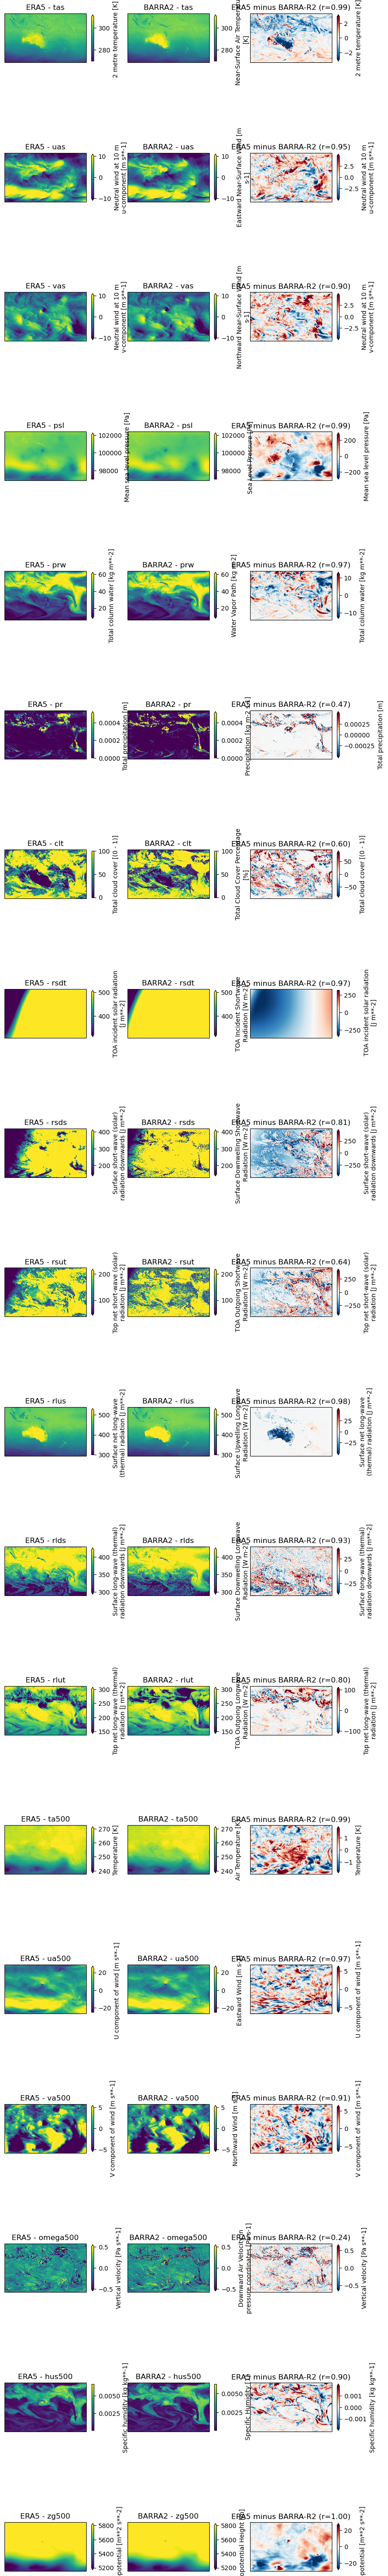

In [39]:
nrows = len(varlist)
fig, axs = plt.subplots(nrows,3, figsize=((10,4*nrows)),subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})

# Let's define the colour range for easier comparison
vminmax = {
    'tas': (270,310),
    'ta500': (240,270),
    'uas': (-10,10),
    'ua500': (-25,25),
    'vas': (-10,10),
    'va500': (-5,5),
    'omega500': (-0.5,0.5),
    'huss': (None, None),
    'hus500': (None, None),
    'ps': (75000,101000),
    'psl': (97000,102000),
    'prw': (10,60),
    'pr': (0,5e-4),
    'clt': (0,100),
    'rsdt': (320,500),
    'rsds': (150,400),
    'rsut': (50,210),
    'rlus': (300,520),
    'rlds': (300,420),
    'rlut': (150,300),
    'zg500': (5200, 5800),
}

# Plot all variable comparisons
for i, var in enumerate(varlist):
    # Get the first sample
    sample = pipe['1979-01-01 00:00']
    a = sample[var].squeeze()
    b = sample[barra2era_map[var]].squeeze()
    r = xr.corr(
        a,
        b
    ).values
    b.plot.pcolormesh(ax=axs[i,0], vmin=vminmax[var][0], vmax=vminmax[var][1], transform=ccrs.PlateCarree(), cbar_kwargs=dict(shrink=0.4))
    a.plot.pcolormesh(ax=axs[i,1], vmin=vminmax[var][0], vmax=vminmax[var][1], transform=ccrs.PlateCarree(), cbar_kwargs=dict(shrink=0.4))
    (b-a).plot.pcolormesh(ax=axs[i,2], robust=True, transform=ccrs.PlateCarree(), cbar_kwargs=dict(shrink=0.4))
    axs[i,0].set_title(f"ERA5 - {var}")
    axs[i,1].set_title(f"BARRA2 - {var}")
    axs[i,2].set_title(f"ERA5 minus BARRA-R2 (r={r:.2f})")